In [1]:
#Examples run from a paper submission in CSNDSP26
from phy import *
from energy import *
import numpy as np
from const import *

In [2]:
design_1 = {
    'environment': {
        'dimensions': np.array([5, 5, 3.0]),
        'wall_resolution': (20, 20),
        'reflectivity': {'floor': 0.6, 'ceiling': 0.6, 'walls': 0.6},
        'special_surfaces': [
            {'type': 'window', 'name': 'win1_west', 'center': [0, 1, 1.5], 'dims': [1, 1], 
             'const_axis': 0, 'normal': SimulationDefaults.xp, 'resolution': (2,2), 'reflectivity': 0.1},
            {'type': 'window', 'name': 'win2_west', 'center': [0, 4, 1.5], 'dims': [1, 1], 
             'const_axis': 0, 'normal': SimulationDefaults.xp, 'resolution': (2,2), 'reflectivity': 0.1},
        ],
    },
    
    'nodes': {
        'masters': {'positions': np.array([2.5,2.5,3]), 'nT': SimulationDefaults.zm},
        'sensors': {
            'positions': np.array([[x, y, 0] for x in np.linspace(0.2,4.8,35) for y in np.linspace(0.2,4.8,35)]),
            'uplink_type': 0, # Alternate IR and RF
          }
    }
}

pn1 = PhyNet(design_1,True)
em1 = EnergyManager(pn1,design_1)


Adding 'win1_west'. Removed 24 tiles.
Adding 'win2_west'. Removed 24 tiles.
Sensors aligned...
There are not any PV-based receivers.
Node ID  Rx           Uplink   Cons/Day(J)     Harv/Day(J)     Net/Day(J)      Life(Days)
-----------------------------------------------------------------------------------------
0        PD           IR       inf             0.00            -inf            0.00      
1        PD           IR       inf             0.00            -inf            0.00      
2        PD           IR       inf             0.00            -inf            0.00      
3        PD           IR       inf             0.00            -inf            0.00      
4        PD           IR       inf             0.00            -inf            0.00      
5        PD           IR       inf             0.00            -inf            0.00      
6        PD           IR       inf             0.00            -inf            0.00      
7        PD           IR       inf             0.00      

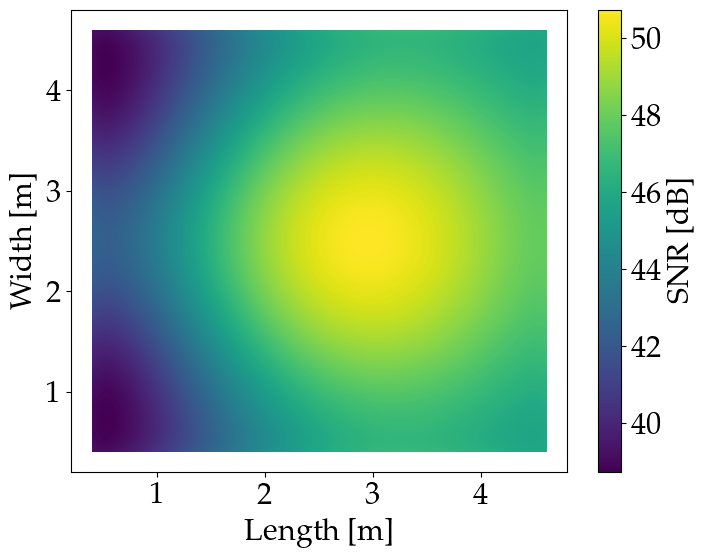

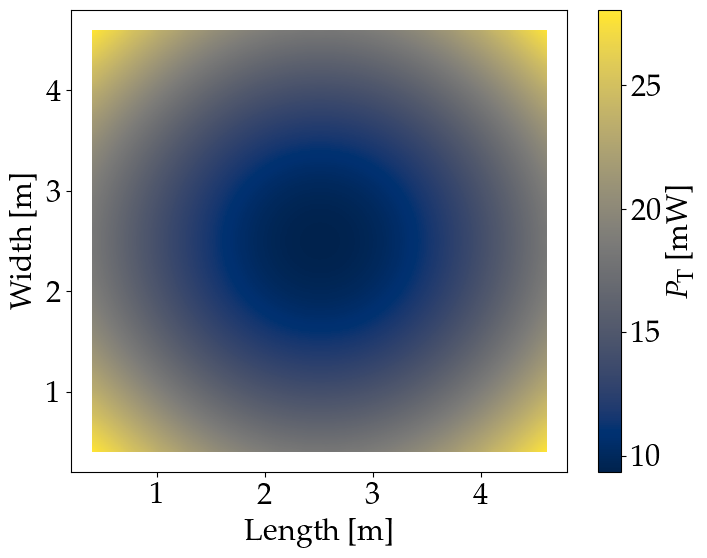

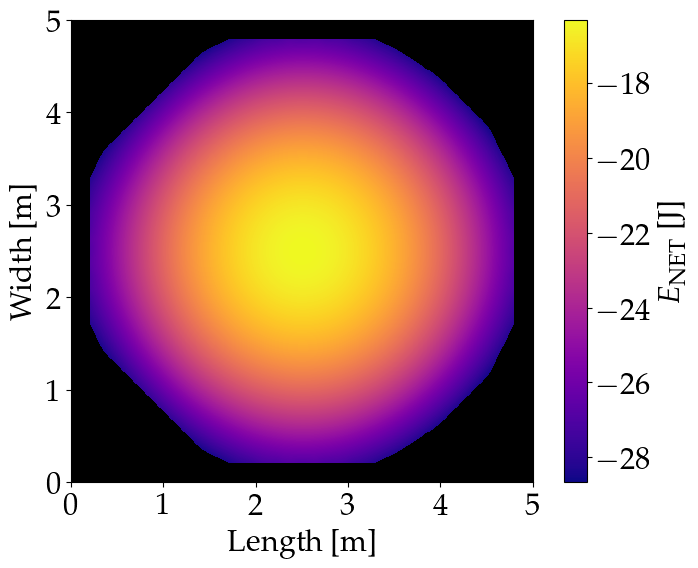

In [4]:
from scipy.interpolate import griddata


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size" : 22,
    "lines.linewidth" : 2,
})

# -----------------------------
# Plot 1: VLC - Total SNR dB (with ambient sunlight)
# -----------------------------
sensor_coords = pn1.snm.ORx_elements.r #x,y coords
x_coords = sensor_coords[:, 0]
y_coords = sensor_coords[:, 1]
grid_x, grid_y = np.linspace(0, 5, 200), np.linspace(0, 5, 200) 
grid_x, grid_y = np.meshgrid(grid_x, grid_y)
snr_grid_interp = griddata(sensor_coords[:, :2], pn1.snr_d_dB, (grid_x, grid_y), method='cubic')
plt.figure(figsize=(8, 6))
plt.imshow(snr_grid_interp, origin='lower', cmap='viridis', extent=(x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()), aspect='auto')
plt.colorbar(label='SNR [dB]')
plt.xlabel('Length [m]')
plt.ylabel('Width [m]')
plt.ion()
plt.savefig("snr_map1_d.pdf", format="pdf", bbox_inches="tight")
plt.show()


# -----------------------------
# Plot 2: Preq - Require power for the uplink 
# -----------------------------
sensor_coords = pn1.snm.ORx_elements.r #x,y coords
x_coords = sensor_coords[:, 0]
y_coords = sensor_coords[:, 1]
grid_x, grid_y = np.linspace(0, 5, 200), np.linspace(0, 5, 200) 
grid_x, grid_y = np.meshgrid(grid_x, grid_y)
snr_grid_interp = griddata(sensor_coords[:, :2], pn1.snm.OTx_elements.p.flatten()*1e3, (grid_x, grid_y), method='cubic')
plt.figure(figsize=(8, 6))
plt.imshow(snr_grid_interp, origin='lower', cmap='cividis', extent=(x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()), aspect='auto')
plt.colorbar(label=r'$P_{\mathrm{T}}$ [mW]')
plt.xlabel('Length [m]')
plt.ylabel('Width [m]')
plt.ion()
plt.savefig("p_map1_u.pdf", format="pdf", bbox_inches="tight")
plt.show()


# -----------------------------
# Plot 3: Net Energy (Black for N/A)
# -----------------------------
from scipy.interpolate import griddata
import matplotlib.cm as cm

# 1. Setup Data
sensor_coords = pn1.snm.ORx_elements.r 
x_coords = sensor_coords[:, 0]
y_coords = sensor_coords[:, 1]
values = em1.E_day_net.flatten()

# 2. Setup Grid
gx_range = np.linspace(0, 5, 500)
gy_range = np.linspace(0, 5, 500)
grid_x, grid_y = np.meshgrid(gx_range, gy_range)



mask_valid = np.isfinite(values)

# Interpolate using ONLY valid data
snr_grid_interp = griddata(
    sensor_coords[mask_valid, :2], 
    values[mask_valid], 
    (grid_x, grid_y), 
    method='cubic'
)


current_cmap = copy.copy(cm.get_cmap("plasma")) # Copy the colormap
current_cmap.set_bad(color='black') # Set the color for NaN/Inf values

# 5. Plotting
fig, ax = plt.subplots(figsize=(8, 6))



im = ax.imshow(
    snr_grid_interp, 
    origin='lower', 
    cmap=current_cmap,
    extent=(gx_range.min(), gx_range.max(), gy_range.min(), gy_range.max()), 
    aspect='equal'
)

# 6. Formatting
cbar = plt.colorbar(im, ax=ax, label=r'$E_{\mathrm{NET}}$ [J]')
ax.set_xlabel('Length [m]')
ax.set_ylabel('Width [m]')
plt.savefig("e_map1_u.pdf", format="pdf", bbox_inches="tight")
plt.ion()
plt.show()


In [9]:
design_2 = {
    'environment': {
        'dimensions': np.array([5, 5, 3.0]),
        'wall_resolution': (20, 20),
        'reflectivity': {'floor': 0.6, 'ceiling': 0.6, 'walls': 0.6},
        'special_surfaces': [
            {'type': 'window', 'name': 'win1_west', 'center': [0, 1, 1.5], 'dims': [1, 1], 
             'const_axis': 0, 'normal': SimulationDefaults.xp, 'resolution': (2,2), 'reflectivity': 0.1},
            {'type': 'window', 'name': 'win2_west', 'center': [0, 4, 1.5], 'dims': [1, 1], 
             'const_axis': 0, 'normal': SimulationDefaults.xp, 'resolution': (2,2), 'reflectivity': 0.1},
            {
                'type': 'RIS', 
                'name': 'ris_west_wall',
                'center': [5, 2.5, 1.5], 
                'dims': [1, 1], 
                'normal': SimulationDefaults.xp, # Pointing into room (+X)
                'const_axis': 0, 
                'resolution': (2,2), 
                'reflectivity': 0.95
            },
        ],
    },
    
    'nodes': {
        'masters': {'positions': np.array([2.5,2.5,3]), 'nT': SimulationDefaults.zm},
        'sensors': {
            'positions': np.array([[x, y, 0] for x in np.linspace(0.2,4.8,20) for y in np.linspace(0.2,4.8,20)]),
            'uplink_type': 0, # Alternate IR and RF
          }
    }
}

pn2 = PhyNet(design_2,True)
em2 = EnergyManager(pn2,design_2)


Adding 'ris_west_wall'. Removed 24 tiles.
Adding 'win1_west'. Removed 24 tiles.
Adding 'win2_west'. Removed 24 tiles.
Sensors aligned...
There are not any PV-based receivers.
Node ID  Rx           Uplink   Cons/Day(J)     Harv/Day(J)     Net/Day(J)      Life(Days)
-----------------------------------------------------------------------------------------
0        PD           IR       18.62           0.00            -18.62          348.10    
1        PD           IR       18.04           0.00            -18.04          359.29    
2        PD           IR       17.49           0.00            -17.49          370.54    
3        PD           IR       16.99           0.00            -16.99          381.46    
4        PD           IR       16.54           0.00            -16.54          391.78    
5        PD           IR       16.15           0.00            -16.15          401.17    
6        PD           IR       15.83           0.00            -15.83          409.26    
7        PD    

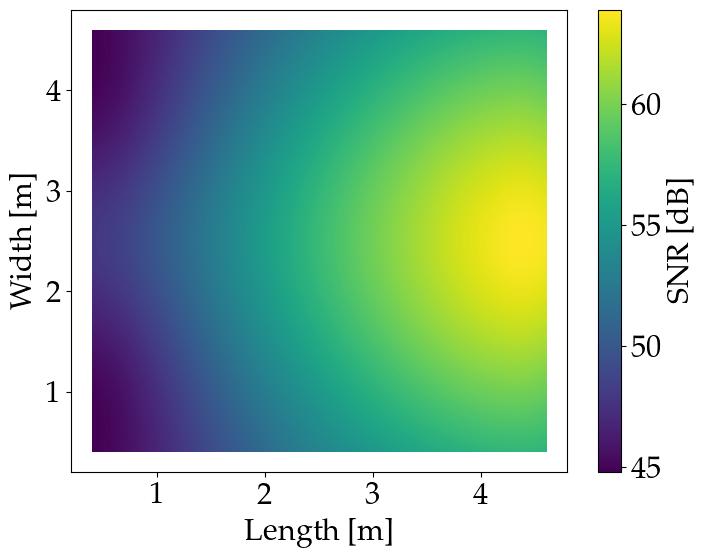

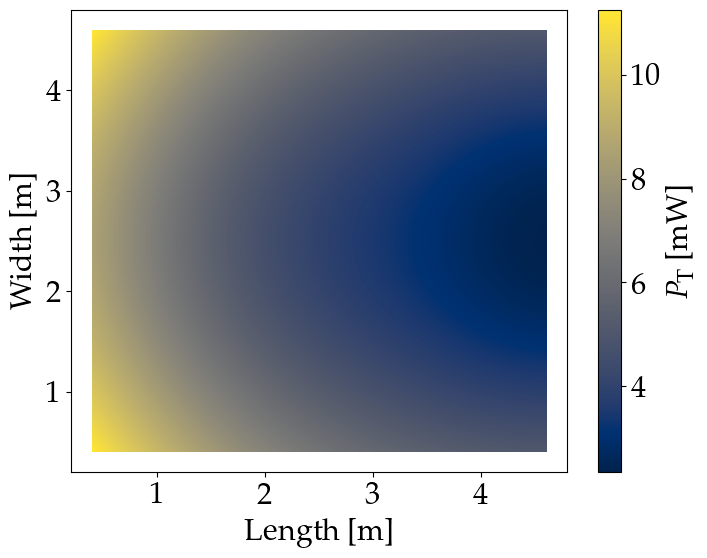

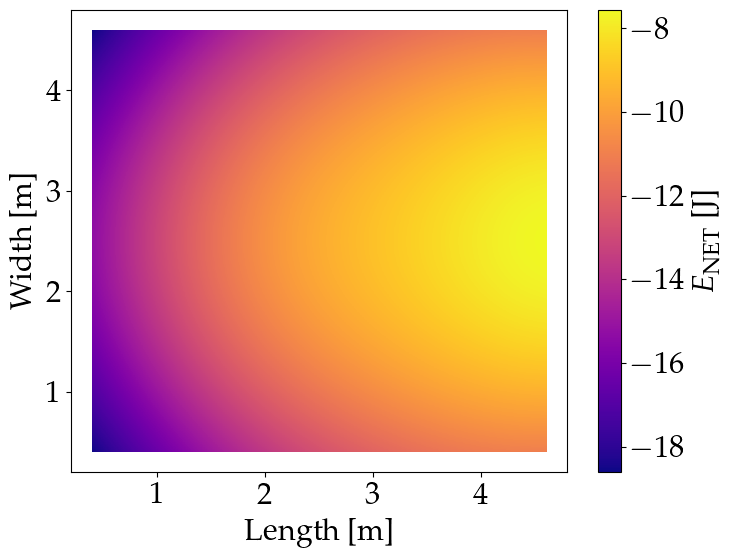

In [11]:
from scipy.interpolate import griddata


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size" : 22,
    "lines.linewidth" : 2,
})

# -----------------------------
# Plot 1: VLC - Total SNR dB (with ambient sunlight)
# -----------------------------
sensor_coords = pn2.snm.ORx_elements.r #x,y coords
x_coords = sensor_coords[:, 0]
y_coords = sensor_coords[:, 1]
grid_x, grid_y = np.linspace(0, 5, 200), np.linspace(0, 5, 200) 
grid_x, grid_y = np.meshgrid(grid_x, grid_y)
snr_grid_interp = griddata(sensor_coords[:, :2], pn2.snr_d_dB, (grid_x, grid_y), method='cubic')
plt.figure(figsize=(8, 6))
plt.imshow(snr_grid_interp, origin='lower', cmap='viridis', extent=(x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()), aspect='auto')
plt.colorbar(label='SNR [dB]')
plt.xlabel('Length [m]')
plt.ylabel('Width [m]')
plt.ion()
plt.savefig("snr_map2_d.pdf", format="pdf", bbox_inches="tight")
plt.show()

# -----------------------------
# Plot 2: Preq - Require power for the uplink 
# -----------------------------
sensor_coords = pn2.snm.ORx_elements.r #x,y coords
x_coords = sensor_coords[:, 0]
y_coords = sensor_coords[:, 1]
grid_x, grid_y = np.linspace(0, 5, 200), np.linspace(0, 5, 200) 
grid_x, grid_y = np.meshgrid(grid_x, grid_y)
snr_grid_interp = griddata(sensor_coords[:, :2], pn2.snm.OTx_elements.p.flatten()*1e3, (grid_x, grid_y), method='cubic')
plt.figure(figsize=(8, 6))
plt.imshow(snr_grid_interp, origin='lower', cmap='cividis', extent=(x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()), aspect='auto')
plt.colorbar(label=r'$P_{\mathrm{T}}$ [mW]')
plt.xlabel('Length [m]')
plt.ylabel('Width [m]')
plt.ion()
plt.savefig("p_map2_u.pdf", format="pdf", bbox_inches="tight")
plt.show()



# -----------------------------
# Plot 3: Net Energy
# -----------------------------
sensor_coords = pn2.snm.ORx_elements.r #x,y coords
x_coords = sensor_coords[:, 0]
y_coords = sensor_coords[:, 1]
grid_x, grid_y = np.linspace(0, 5, 200), np.linspace(0, 5, 200) 
grid_x, grid_y = np.meshgrid(grid_x, grid_y)
snr_grid_interp = griddata(sensor_coords[:, :2], em2.E_day_net.flatten(), (grid_x, grid_y), method='cubic')
plt.figure(figsize=(8, 6))
plt.imshow(snr_grid_interp, origin='lower', cmap='plasma', extent=(x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()), aspect='auto')
plt.colorbar(label=r'$E_{\mathrm{NET}}$ [J]')
plt.xlabel('Length [m]')
plt.ylabel('Width [m]')
plt.ion()
plt.savefig("e_map2_u.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [12]:
design_3 = {
    'environment': {
        'dimensions': np.array([5, 5, 3.0]),
        'wall_resolution': (20, 20),
        'reflectivity': {'floor': 0.6, 'ceiling': 0.6, 'walls': 0.6},
        'special_surfaces': [
            {'type': 'window', 'name': 'win1_west', 'center': [0, 1, 1.5], 'dims': [1, 1], 
             'const_axis': 0, 'normal': SimulationDefaults.xp, 'resolution': (2,2), 'reflectivity': 0.1},
            {'type': 'window', 'name': 'win2_west', 'center': [0, 4, 1.5], 'dims': [1, 1], 
             'const_axis': 0, 'normal': SimulationDefaults.xp, 'resolution': (2,2), 'reflectivity': 0.1},
        ],
    },
    
    'nodes': {
        'masters': {
            'positions': np.array([[2.5, 2.5, 3]]), 
            'nT': SimulationDefaults.zm, 
        },
        'sensors': {
            'positions': np.array([[x, y, 0] for x in np.linspace(0.2, 4.8, 7) for y in np.linspace(0.2, 4.8, 7)]),
            'uplink_type': 1, 
            'rx_type': 1,
            'rx_area': 5e-4
          },
    }, 

    'communication': {
        'Rb_up': 5e3,    
    }
}

pn3 = PhyNet(design_3,True)
em3 = EnergyManager(pn3,design_3)

Adding 'win1_west'. Removed 24 tiles.
Adding 'win2_west'. Removed 24 tiles.
Node ID  Rx           Uplink   Cons/Day(J)     Harv/Day(J)     Net/Day(J)      Life(Days)
-----------------------------------------------------------------------------------------
0        PV           RF       3.16            128.15          124.99          Inf       
1        PV           RF       3.16            135.63          132.46          Inf       
2        PV           RF       3.16            111.51          108.35          Inf       
3        PV           RF       3.16            91.24           88.07           Inf       
4        PV           RF       3.16            111.51          108.35          Inf       
5        PV           RF       3.16            135.63          132.46          Inf       
6        PV           RF       3.16            128.15          124.99          Inf       
7        PV           RF       3.16            91.77           88.60           Inf       
8        PV           RF

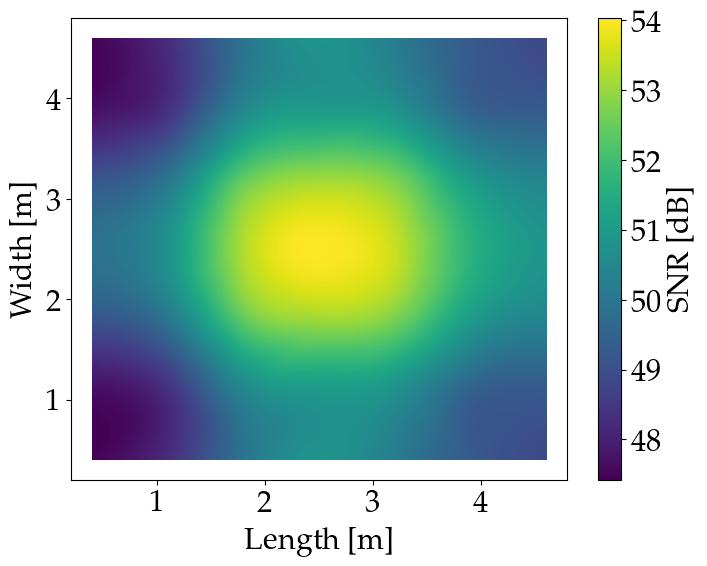

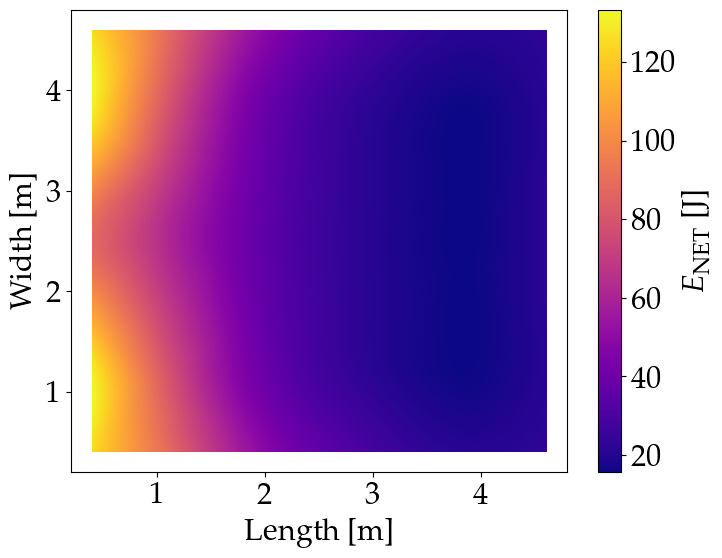

In [13]:
from scipy.interpolate import griddata


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size" : 22,
    "lines.linewidth" : 2,
})

# -----------------------------
# Plot 1: VLC - Total SNR dB (with ambient sunlight)
# -----------------------------
sensor_coords = pn3.snm.ORx_elements.r #x,y coords
x_coords = sensor_coords[:, 0]
y_coords = sensor_coords[:, 1]
grid_x, grid_y = np.linspace(0, 5, 200), np.linspace(0, 5, 200) 
grid_x, grid_y = np.meshgrid(grid_x, grid_y)
snr_grid_interp = griddata(sensor_coords[:, :2], pn3.snr_d_dB, (grid_x, grid_y), method='cubic')
plt.figure(figsize=(8, 6))
plt.imshow(snr_grid_interp, origin='lower', cmap='viridis', extent=(x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()), aspect='auto')
plt.colorbar(label='SNR [dB]')
plt.xlabel('Length [m]')
plt.ylabel('Width [m]')
plt.ion()
plt.savefig("snr_map3_d.pdf", format="pdf", bbox_inches="tight")
plt.show()



# -----------------------------
# Plot 2: Net Energy
# -----------------------------
sensor_coords = pn3.snm.ORx_elements.r 
x_coords = sensor_coords[:, 0]
y_coords = sensor_coords[:, 1]
grid_x, grid_y = np.linspace(0, 5, 200), np.linspace(0, 5, 200) 
grid_x, grid_y = np.meshgrid(grid_x, grid_y)
snr_grid_interp = griddata(sensor_coords[:, :2], em3.E_day_net.flatten(), (grid_x, grid_y), method='cubic')
plt.figure(figsize=(8, 6))
plt.imshow(snr_grid_interp, origin='lower', cmap='plasma', extent=(x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()), aspect='auto')
plt.colorbar(label=r'$E_{\mathrm{NET}}$ [J]')
plt.xlabel('Length [m]')
plt.ylabel('Width [m]')
plt.ion()
plt.savefig("snr_map3_u.pdf", format="pdf", bbox_inches="tight")
plt.show()
